In [594]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

import matplotlib
matplotlib.rcParams["figure.figsize"] = (20,10)

In [595]:
df1= pd.read_csv("Data/bengaluru_house_prices.csv")
df1.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [596]:
df1.shape

(13320, 9)

In [597]:
print(df1.isnull().sum())

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64


In [598]:
df1.groupby('area_type')['area_type'].agg('count')

area_type
Built-up  Area          2418
Carpet  Area              87
Plot  Area              2025
Super built-up  Area    8790
Name: area_type, dtype: int64

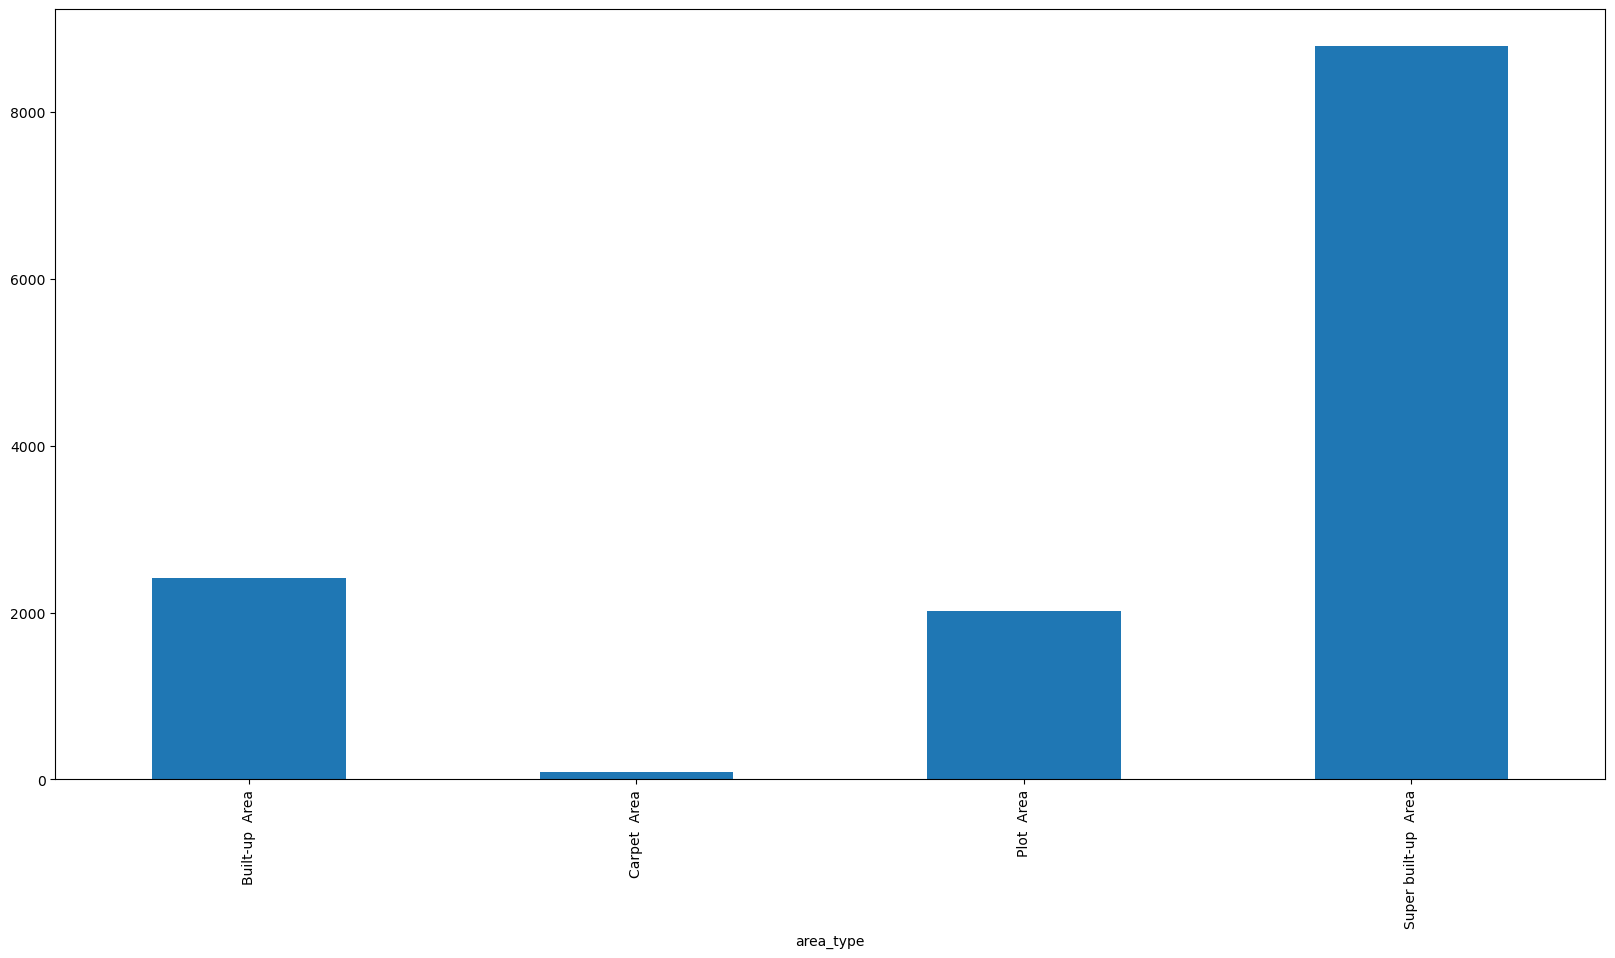

In [599]:
df1.groupby('area_type')['area_type'].agg('count').plot(kind='bar')
plt.show()

In [600]:
df2.isnull().sum()

location        1
size           16
total_sqft      0
bath           73
balcony       609
price           0
dtype: int64

In [601]:
# Missing rows are relatively small compared with the full dataset
df3 = df2.dropna()

In [602]:
df3.isnull().sum()

location      0
size          0
total_sqft    0
bath          0
balcony       0
price         0
dtype: int64

In [603]:
df3.shape

(12710, 6)

In [604]:
df3.head()

,location,size,total_sqft,bath,balcony,price
0,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Kothanur,2 BHK,1200,2.0,1.0,51.00


In [605]:
# Convert size → bhk

df3['bhk'] = df3['size'].apply(
    lambda x: int(x.split(' ')[0])
)

df3.head()

C:\Users\utkar\AppData\Local\Temp\ipykernel_8736\1080409918.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['bhk'] = df3['size'].apply(


,location,size,total_sqft,bath,balcony,price,bhk
0,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,2
1,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,4
2,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,3
3,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,3
4,Kothanur,2 BHK,1200,2.0,1.0,51.00,2


In [606]:
df4=df3.drop('size', axis=1)

In [607]:
df4.head()

,location,total_sqft,bath,balcony,price,bhk
0,Electronic City Phase II,1056,2.0,1.0,39.07,2
1,Chikka Tirupathi,2600,5.0,3.0,120.00,4
2,Uttarahalli,1440,2.0,3.0,62.00,3
3,Lingadheeranahalli,1521,3.0,1.0,95.00,3
4,Kothanur,1200,2.0,1.0,51.00,2


In [608]:
# Check problematic values: 
def is_float(x):
    try:
        float(x)
    except:
        return False
    return True

df4[~df4['total_sqft'].apply(is_float)].head(10)

,location,total_sqft,bath,balcony,price,bhk
30,Yelahanka,2100 - 2850,4.0,0.0,186.000,4
122,Hebbal,3067 - 8156,4.0,0.0,477.000,4
137,8th Phase JP Nagar,1042 - 1105,2.0,0.0,54.005,2
165,Sarjapur,1145 - 1340,2.0,0.0,43.490,2
188,KR Puram,1015 - 1540,2.0,0.0,56.800,2
410,Kengeri,34.46Sq. Meter,1.0,0.0,18.500,1
549,Hennur Road,1195 - 1440,2.0,0.0,63.770,2
661,Yelahanka,1120 - 1145,2.0,0.0,48.130,2
672,Bettahalsoor,3090 - 5002,4.0,0.0,445.000,4
772,Banashankari Stage VI,1160 - 1195,2.0,0.0,59.935,2


In [609]:
# Solution of this problem 
def convert_sqft_to_num(x):
    
    token = x.split('-')
    
    if len(token) == 2:
        return (float(token[0]) + float(token[1])) / 2
    
    try:
        return float(x)
    
    except:
        return None

In [610]:
df5 = df4.copy()

df5['total_sqft'] = df5['total_sqft'].apply(
    convert_sqft_to_num
)

df5.head()

,location,total_sqft,bath,balcony,price,bhk
0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2
1,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4
2,Uttarahalli,1440.0,2.0,3.0,62.00,3
3,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3
4,Kothanur,1200.0,2.0,1.0,51.00,2


In [611]:
df5 = df5.dropna()

print(df5.shape)

(12668, 6)


In [612]:
# create a feature price_per_sqft
df5['price_per_sqft'] = (
    df5['price'] * 100000
) / df5['total_sqft']

df5.head()

,location,total_sqft,bath,balcony,price,bhk,price_per_sqft
0,Electronic City Phase II,1056.0,2.0,1.0,39.07,2,3699.810606
1,Chikka Tirupathi,2600.0,5.0,3.0,120.00,4,4615.384615
2,Uttarahalli,1440.0,2.0,3.0,62.00,3,4305.555556
3,Lingadheeranahalli,1521.0,3.0,1.0,95.00,3,6245.890861
4,Kothanur,1200.0,2.0,1.0,51.00,2,4250.000000


In [613]:
print(len(df5.location.unique()))


1259


In [614]:
# This is too many for direct encoding because one-hot encoding would create 1259 new columns, making the model unnecessarily large.
# Remove extra spaces if any
df5.location = df5.location.apply(
    lambda x: x.strip()
)

# Count occurrences of each location
location_stats = df5.groupby('location')['location'].agg('count')

# Show top locations
print(location_stats.sort_values(ascending=False))

location
Whitefield              514
Sarjapur  Road          372
Electronic City         302
Kanakpura Road          259
Thanisandra             233
                       ... 
1 Giri Nagar              1
Kanakapura  Rod           1
Kanakapura Main Road      1
Kanakapura Road           1
whitefiled                1
Name: location, Length: 1248, dtype: int64


In [615]:
location_stats_less_than_10 = location_stats[
    location_stats <= 10
]

print(len(location_stats_less_than_10))

1013


In [616]:
df5.location = df5.location.apply(
    lambda x: 'other'
    if x in location_stats_less_than_10
    else x
)

print(len(df5.location.unique()))

236


In [617]:
# Remove Outlier 
# Remove price_per_sqft outliers
def remove_pps_outliers(df):
    
    df_out = pd.DataFrame()
    
    for key, subdf in df.groupby('location'):
        
        m = np.mean(subdf.price_per_sqft)
        st = np.std(subdf.price_per_sqft)
        
        reduced_df = subdf[
            (subdf.price_per_sqft > (m - st))
            &
            (subdf.price_per_sqft <= (m + st))
        ]
        
        df_out = pd.concat([df_out, reduced_df],
                           ignore_index=True)
        
    return df_out


df6 = remove_pps_outliers(df5)

print(df5.shape)
print(df6.shape)

(12668, 7)
(10826, 7)


In [618]:
# Remove BHK outlier 
df7 = df6[
    df6.total_sqft / df6.bhk >= 300
]

print(df6.shape)
print(df7.shape)

(10826, 7)
(10420, 7)


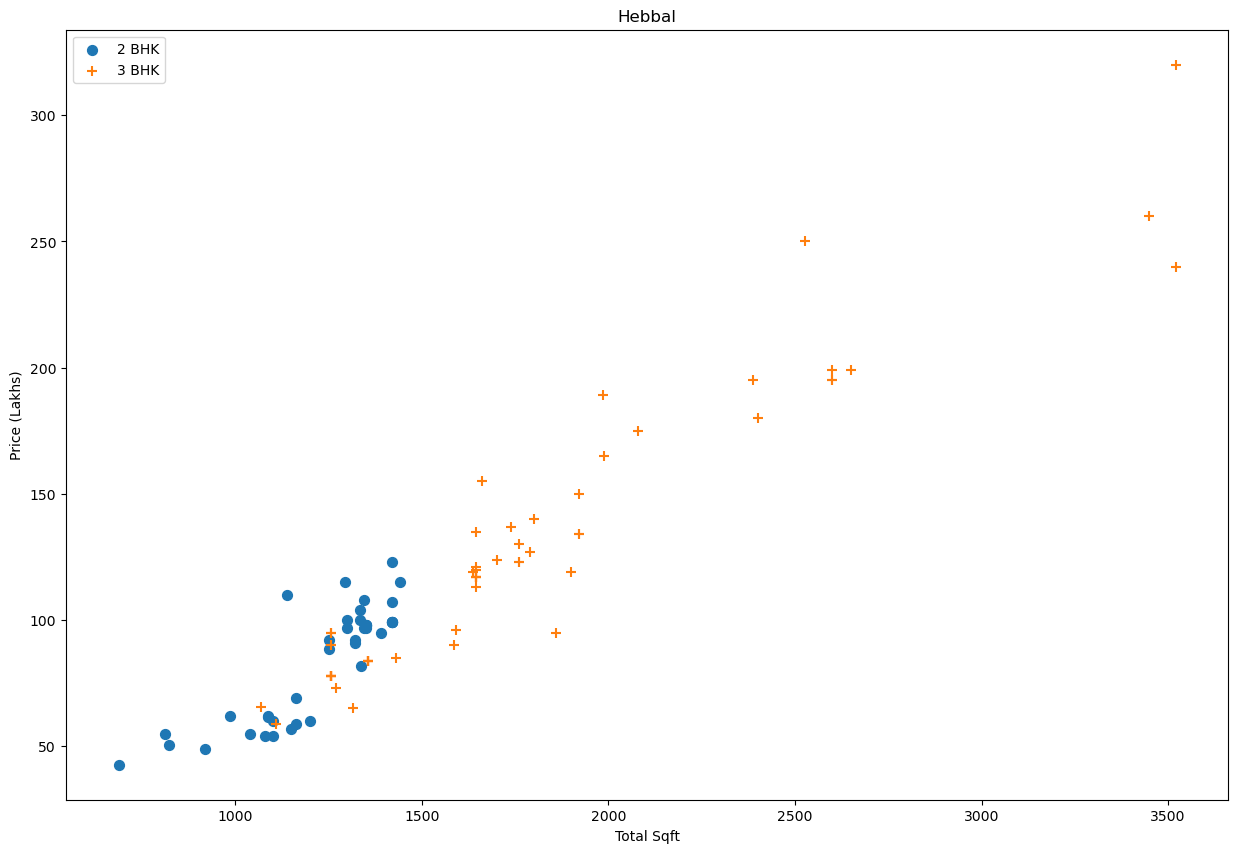

In [619]:
# If in the same location, a 3 BHK has lower price per sqft than a 2 BHK, that can be suspicious. 
# check it with visualization 
import matplotlib.pyplot as plt

def plot_scatter_chart(df, location):

    bhk2 = df[
        (df.location == location) &
        (df.bhk == 2)
    ]

    bhk3 = df[
        (df.location == location) &
        (df.bhk == 3)
    ]

    plt.figure(figsize=(15,10))

    plt.scatter(
        bhk2.total_sqft,
        bhk2.price,
        label='2 BHK',
        s=50
    )

    plt.scatter(
        bhk3.total_sqft,
        bhk3.price,
        label='3 BHK',
        marker='+',
        s=50
    )

    plt.xlabel("Total Sqft")
    plt.ylabel("Price (Lakhs)")
    plt.title(location)
    plt.legend()

plot_scatter_chart(df6, "Hebbal")

plt.show()

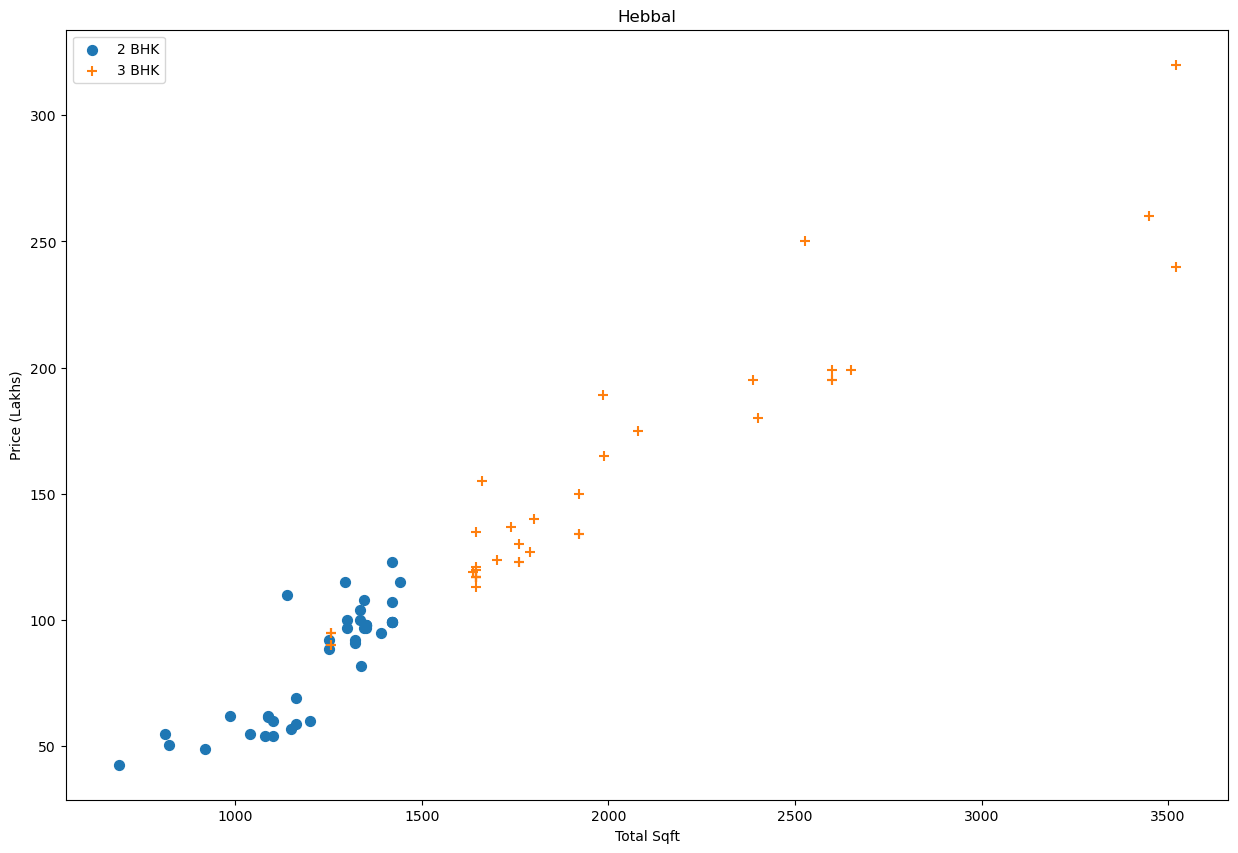

In [620]:
# Remove BHK outliers
def remove_bhk_outliers(df):

    exclude_indices = np.array([])

    for location, location_df in df.groupby('location'):

        bhk_stats = {}

        for bhk, bhk_df in location_df.groupby('bhk'):

            bhk_stats[bhk] = {
                'mean': np.mean(bhk_df.price_per_sqft),
                'std': np.std(bhk_df.price_per_sqft),
                'count': bhk_df.shape[0]
            }

        for bhk, bhk_df in location_df.groupby('bhk'):

            stats = bhk_stats.get(bhk-1)

            if stats and stats['count'] > 5:

                exclude_indices = np.append(
                    exclude_indices,
                    bhk_df[
                        bhk_df.price_per_sqft < stats['mean']
                    ].index.values
                )

    return df.drop(exclude_indices, axis='index')


# Call function OUTSIDE
df7 = remove_bhk_outliers(df6)

# Plot after removing outliers
plot_scatter_chart(df7, "Hebbal")

plt.show()

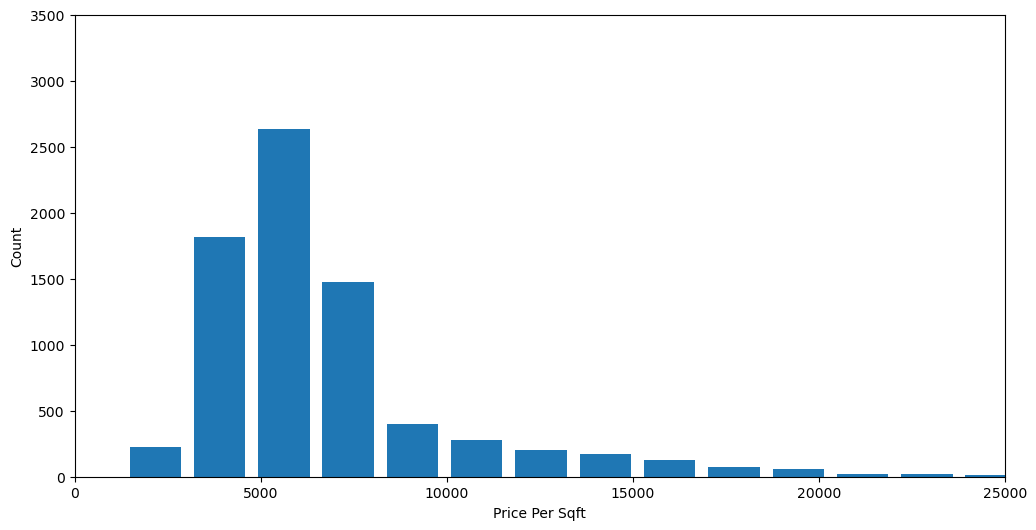

In [621]:
plt.figure(figsize=(12,6))

plt.hist(df7['price_per_sqft'],
         bins=30,
         rwidth=0.8)

plt.xlabel("Price Per Sqft")
plt.ylabel("Count")

# Set axis range
plt.xlim(0,25000)
plt.ylim(0,3500)

plt.show()

In [622]:
# Now check Bathroom 
df7.bath.unique()

array([ 4.,  3.,  6.,  2.,  1.,  5.,  8.,  7.,  9., 10., 27., 11., 15.,
       13.])

In [623]:
df7[df7.bath>10]

,location,total_sqft,bath,balcony,price,bhk,price_per_sqft
8440,other,8000.0,27.0,0.0,230.0,27,2875.000000
8449,other,1200.0,11.0,0.0,170.0,11,14166.666667
9096,other,1250.0,15.0,0.0,125.0,14,10000.000000
10107,other,5425.0,13.0,0.0,275.0,13,5069.124424


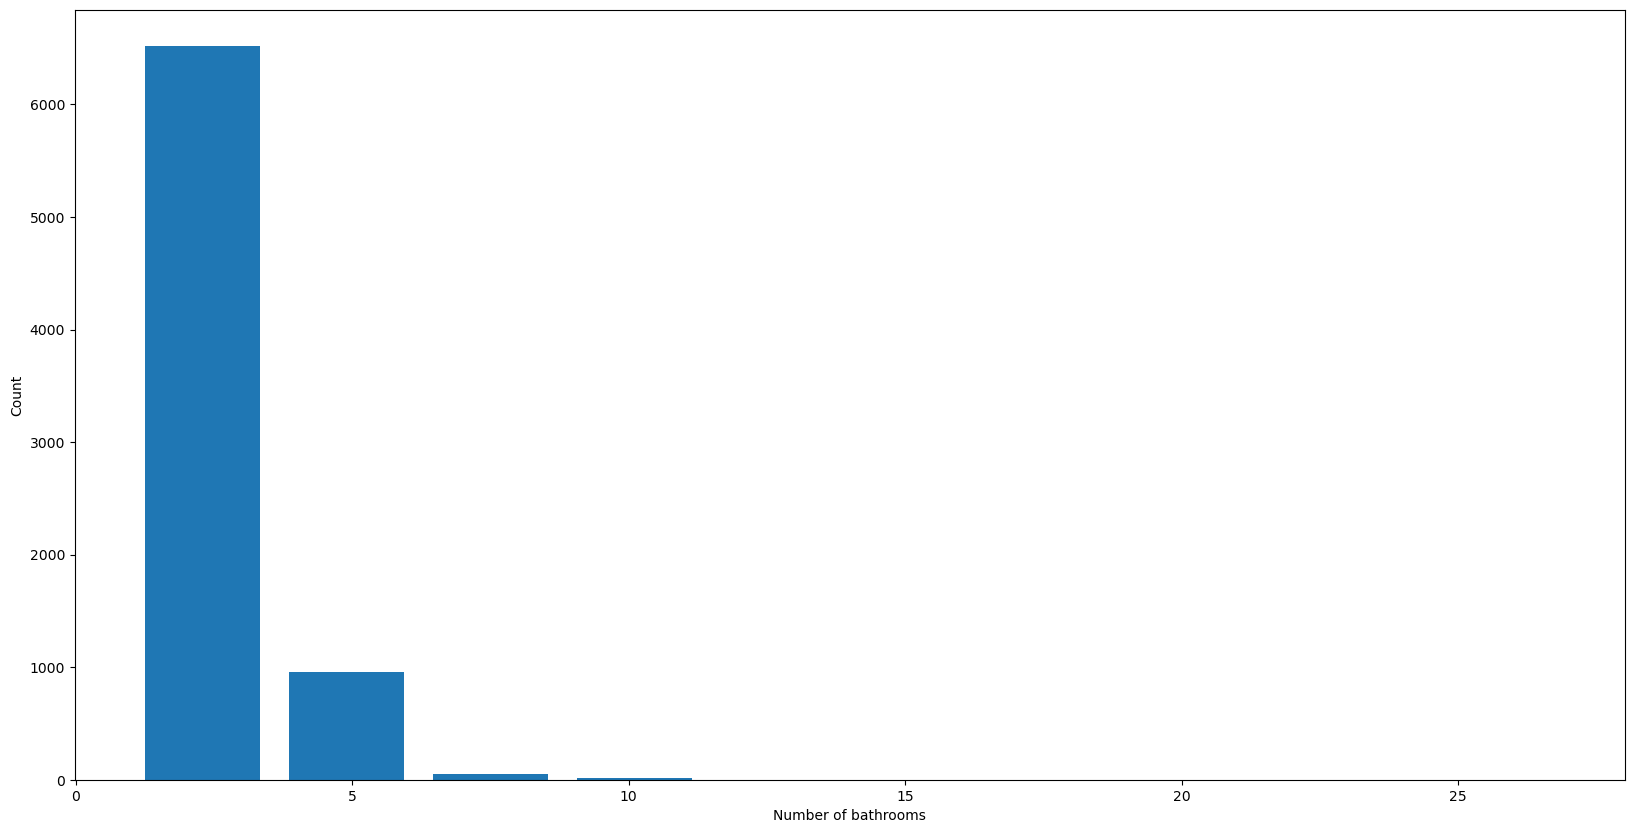

In [624]:
plt.hist(df7.bath, rwidth=0.8)
plt.xlabel("Number of bathrooms")
plt.ylabel("Count")
plt.show()

In [625]:
# Use this formula 
df8 = df7[df7.bath < df7.bhk + 2]

print(df7.shape)
print(df8.shape)

(7542, 7)
(7459, 7)


In [626]:
df9 = df8.drop(
    ['price_per_sqft','balcony'],
    axis=1
)

df9.head()

,location,total_sqft,bath,price,bhk
0,1st Block Jayanagar,2850.0,4.0,428.0,4
1,1st Block Jayanagar,1630.0,3.0,194.0,3
2,1st Block Jayanagar,1200.0,6.0,125.0,6
3,1st Block Jayanagar,1875.0,2.0,235.0,3
4,1st Block Jayanagar,930.0,4.0,85.0,7


In [627]:
# One hot Encoding 
dummies = pd.get_dummies(df9.location)

dummies.head()

,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Phase JP Nagar,6th Phase JP Nagar,7th Phase JP Nagar,8th Phase JP Nagar,9th Phase JP Nagar,AECS Layout,...,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur,other
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [628]:
# Convert True/False to 0/1
dummies = dummies.astype(int)

In [629]:
df10 = pd.concat(
    [df9, dummies.drop('other', axis=1)],
    axis=1
)

df10.head()

,location,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,1st Block Jayanagar,2850.0,4.0,428.0,4,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1st Block Jayanagar,1630.0,3.0,194.0,3,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1st Block Jayanagar,1200.0,6.0,125.0,6,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1st Block Jayanagar,1875.0,2.0,235.0,3,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1st Block Jayanagar,930.0,4.0,85.0,7,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [630]:
#Remove original location column
df11 = df10.drop(
    'location',
    axis=1
)

df11.head()

,total_sqft,bath,price,bhk,1st Block Jayanagar,1st Phase JP Nagar,2nd Phase Judicial Layout,2nd Stage Nagarbhavi,5th Phase JP Nagar,6th Phase JP Nagar,...,Vijayanagar,Vishveshwarya Layout,Vishwapriya Layout,Vittasandra,Whitefield,Yelachenahalli,Yelahanka,Yelahanka New Town,Yelenahalli,Yeshwanthpur
0,2850.0,4.0,428.0,4,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1630.0,3.0,194.0,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1200.0,6.0,125.0,6,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1875.0,2.0,235.0,3,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,930.0,4.0,85.0,7,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [631]:
# Separate input and output


x = df11.drop('price', axis=1)
y = df11['price']


In [632]:
print(x.shape)
print(y.shape)

(7459, 238)
(7459,)


In [633]:
# Split train and test data
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=10
)

In [634]:
# Train Linear Regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train, y_train)

LinearRegression()

In [635]:
# Check model score
print(model.score(x_train,y_train))
print(model.score(x_test, y_test))

0.6853704214712463
0.7148089205479173


In [638]:
def predict_price(location, total_sqft, bath, bhk):

    loc_index = np.where(x.columns == location)[0]

    z = np.zeros(len(x.columns))

    # numerical features
    z[0] = total_sqft
    z[1] = bath
    z[2] = bhk

    # location encoding
    if len(loc_index) > 0:
        z[loc_index[0]] = 1

    return model.predict([z])[0]

In [644]:
print(predict_price(
    '1st Phase JP Nagar',
    1000,
    2,
    2
) )
print(predict_price('Whitefield',1500,3,3))

print(predict_price('Electronic City Phase II',1200,2,2))

print(predict_price('Indira Nagar',1000,2,2))

74.75556113611408
104.5474516548623
51.42986565206722
142.00245932855182


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [647]:
import pickle
import json

# Save model
with open('house_price_model.pkl','wb') as f:
    pickle.dump(model,f)

# Save columns
columns = {
    'data_columns': [col.lower() for col in x.columns]
}

with open("columns.json","w") as f:
    json.dump(columns,f)

print("Model and columns saved successfully")

Model and columns saved successfully
